In [100]:
import numpy as np
import polars as pl

In [101]:
df = pl.read_csv('data_neural_network.csv')

Nas camadas ocultas será utilizado uma função de ativação, ReLU ou Tanh. Na camada de saída, devemos usar uma função que sirva para regressão como uma ativação linear para valores contínuos.
A função de custo para valores contínuos, regressão, usaremos o Erro Quadrático Médio.
E teremos que usar um otimizador como Adam ou SGD. É uma rede neural de regressão multiple-output pois queremos encontrar a energia e a composição e talvez outras grandezas a partir da densidade.

In [102]:
df

TRIG,density,composition,energy,density_normalized
str,f64,str,f64,f64
"""TRIG65""",0.35,"""Photon""",1.0000e14,0.001325
"""TRIG29""",3.76,"""Proton""",2.1500e15,0.014233
"""TRIG54""",20.14,"""Iron""",4.6400e15,0.076239
"""TRIG27""",0.05,"""Iron""",1.0000e14,0.000189
"""TRIG68""",1.2,"""Photon""",4.6400e14,0.004543
"""TRIG28""",2.53,"""Proton""",1.0000e15,0.009577
"""TRIG58""",9.49,"""Iron""",4.6400e15,0.035924
"""TRIG27""",1.18,"""Proton""",4.6400e14,0.004467
"""TRIG47""",10.27,"""Photon""",1.0000e15,0.038876


In [103]:
# Excluir a coluna density que não está normalizada
df = df.drop('density')
# Conversão de strings para números
mapper = {
    'Photon':1,
    'Proton':float(np.log(1)),
    'Iron':float(np.log(56))
}

trigs = []
for i in range(1,101):
    trig = 'TRIG' + str(i)
    trigs.append(trig)

trigs = dict((list(enumerate(trigs, 1))))

trigs = {value: key for key, value in trigs.items()}

df = df.with_columns(
    pl.col('composition').map_dict(mapper, default=None),
    pl.col('TRIG').map_dict(trigs, default=None)
    )

In [104]:
df_grouped = df.group_by(["energy", "composition", "TRIG"]).agg([
    pl.col("density_normalized").first()
])

In [105]:
df_neural = df_grouped.pivot(
    values="density_normalized",
    index=["energy", "composition"],
    columns="TRIG"
)
# Estrutura em ordem numérica
df_neural = df_neural.select(
    ['energy', 'composition'] + [f"{i}" for i in range(1, 101)]
)

In [106]:
df_neural

energy,composition,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,…,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0000e15,0.0,0.002574,0.003331,0.005186,0.005451,0.005792,0.006814,0.005224,0.004202,0.003104,0.002726,0.003748,0.004656,0.006662,0.008669,0.00988,0.009956,0.009047,0.006511,0.005565,0.003293,0.004921,0.0067,0.010448,0.015445,0.019571,0.020025,0.014725,0.009577,0.007344,0.004505,0.005224,0.008139,0.015445,0.024984,0.041526,…,0.025287,0.041261,0.040239,0.026725,0.013476,0.009123,0.005413,0.00511,0.007495,0.010296,0.014347,0.019079,0.018738,0.014347,0.008858,0.006435,0.00458,0.003937,0.00583,0.0067,0.009009,0.010183,0.011546,0.00882,0.006965,0.004694,0.00424,0.002574,0.00318,0.005035,0.005262,0.005792,0.007117,0.006435,0.004997,0.003558,0.002839
1.0000e13,1.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,…,0.000038,0.000038,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.000038,0.000038,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2.1500e15,0.0,0.006814,0.007987,0.009956,0.012871,0.012757,0.014006,0.012492,0.009501,0.007533,0.005792,0.007154,0.011583,0.015445,0.019079,0.021766,0.021463,0.020593,0.014271,0.012871,0.008934,0.010334,0.015255,0.02453,0.033615,0.040883,0.042775,0.031192,0.022751,0.014233,0.011318,0.012227,0.018662,0.030511,0.058864,0.088882,…,0.057955,0.085362,0.087368,0.056895,0.033274,0.020176,0.012946,0.010334,0.01499,0.025097,0.032101,0.040958,0.039066,0.034675,0.022675,0.015975,0.010561,0.008517,0.011962,0.01518,0.02029,0.023318,0.023129,0.019949,0.014574,0.012038,0.008214,0.005375,0.007874,0.009009,0.012378,0.013211,0.014536,0.012151,0.010183,0.008669,0.006322
4.6400e15,4.025352,0.007003,0.008934,0.010561,0.012,0.01465,0.012454,0.011205,0.010561,0.008328,0.0067,0.007987,0.011205,0.014801,0.019987,0.023205,0.022334,0.020176,0.015482,0.010675,0.007684,0.010637,0.015823,0.021539,0.030662,0.038952,0.037703,0.034448,0.023394,0.014006,0.010713,0.012151,0.020063,0.033274,0.052883,0.082258,…,0.053867,0.076542,0.07639,0.050271,0.029564,0.019495,0.011583,0.010183,0.016202,0.023545,0.03316,0.041905,0.039293,0.033047,0.022145,0.016505,0.010524,0.008063,0.011053,0.015634,0.018511,0.025552,0.021312,0.018776,0.015672,0.010751,0.00829,0.006246,0.008669,0.009615,0.013135,0.01446,0.014763,0.013173,0.011129,0.008669,0.006814
4.6400e15,1.0,0.020441,0.028164,0.036454,0.045312,0.051596,0.050649,0.046485,0.038498,0.029261,0.022031,0.026422,0.038914,0.054965,0.0748,0.084377,0.086346,0.076163,0.055305,0.039217,0.029489,0.037022,0.054965,0.082674,0.125639,0.159556,0.159973,0.127872,0.086611,0.053223,0.036719,0.043911,0.069955,0.124049,0.223,0.352614,…,0.218912,0.357497,0.360071,0.225234,0.127304,0.069614,0.043305,0.035242,0.05398,0.085551,0.122762,0.159367,0.16319,0.127229,0.085021,0.056706,0.034448,0.029072,0.03846,0.054321,0.072378,0.083393,0.088049,0.073589,0.054775,0.041488,0.02911,0.021691,0.028996,0.0374,0.044025,0.052731,0.051709,0.04535,0.038347,0.029375,0.02328
1.0000e15,1.0,0.003255,0.003785,0.004353,0.005943,0.006587,0.00617,0.005224,0.00458,0.00405,0.002536,0.003899,0.004997,0.007117,0.008139,0.011811,0.00988,0.008479,0.006965,0.005148,0.004278,0.004618,0.007647,0.009804,0.015785,0.020593,0.018662,0.014006,0.010296,0.007647,0.004391,0.00511,0.008858,0.014423,0.024984,0.040164,…,0.026385,0.041791,0.040429,0.026271,0.016126,0.009842,0.005905,0.004088,0.007457,0.010902,0.014688,0.019987,0.0187,0.01446,0.011243,0.007684,0.004505,0.003823,0

In [107]:
# Log da energia
    
df_neural = df_neural.with_columns(
      ((pl.col('energy').log10()))
    )
df_neural

energy,composition,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,…,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
15.0,0.0,0.002574,0.003331,0.005186,0.005451,0.005792,0.006814,0.005224,0.004202,0.003104,0.002726,0.003748,0.004656,0.006662,0.008669,0.00988,0.009956,0.009047,0.006511,0.005565,0.003293,0.004921,0.0067,0.010448,0.015445,0.019571,0.020025,0.014725,0.009577,0.007344,0.004505,0.005224,0.008139,0.015445,0.024984,0.041526,…,0.025287,0.041261,0.040239,0.026725,0.013476,0.009123,0.005413,0.00511,0.007495,0.010296,0.014347,0.019079,0.018738,0.014347,0.008858,0.006435,0.00458,0.003937,0.00583,0.0067,0.009009,0.010183,0.011546,0.00882,0.006965,0.004694,0.00424,0.002574,0.00318,0.005035,0.005262,0.005792,0.007117,0.006435,0.004997,0.003558,0.002839
13.0,1.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,…,0.000038,0.000038,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.000038,0.000038,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15.332438,0.0,0.006814,0.007987,0.009956,0.012871,0.012757,0.014006,0.012492,0.009501,0.007533,0.005792,0.007154,0.011583,0.015445,0.019079,0.021766,0.021463,0.020593,0.014271,0.012871,0.008934,0.010334,0.015255,0.02453,0.033615,0.040883,0.042775,0.031192,0.022751,0.014233,0.011318,0.012227,0.018662,0.030511,0.058864,0.088882,…,0.057955,0.085362,0.087368,0.056895,0.033274,0.020176,0.012946,0.010334,0.01499,0.025097,0.032101,0.040958,0.039066,0.034675,0.022675,0.015975,0.010561,0.008517,0.011962,0.01518,0.02029,0.023318,0.023129,0.019949,0.014574,0.012038,0.008214,0.005375,0.007874,0.009009,0.012378,0.013211,0.014536,0.012151,0.010183,0.008669,0.006322
15.666518,4.025352,0.007003,0.008934,0.010561,0.012,0.01465,0.012454,0.011205,0.010561,0.008328,0.0067,0.007987,0.011205,0.014801,0.019987,0.023205,0.022334,0.020176,0.015482,0.010675,0.007684,0.010637,0.015823,0.021539,0.030662,0.038952,0.037703,0.034448,0.023394,0.014006,0.010713,0.012151,0.020063,0.033274,0.052883,0.082258,…,0.053867,0.076542,0.07639,0.050271,0.029564,0.019495,0.011583,0.010183,0.016202,0.023545,0.03316,0.041905,0.039293,0.033047,0.022145,0.016505,0.010524,0.008063,0.011053,0.015634,0.018511,0.025552,0.021312,0.018776,0.015672,0.010751,0.00829,0.006246,0.008669,0.009615,0.013135,0.01446,0.014763,0.013173,0.011129,0.008669,0.006814
15.666518,1.0,0.020441,0.028164,0.036454,0.045312,0.051596,0.050649,0.046485,0.038498,0.029261,0.022031,0.026422,0.038914,0.054965,0.0748,0.084377,0.086346,0.076163,0.055305,0.039217,0.029489,0.037022,0.054965,0.082674,0.125639,0.159556,0.159973,0.127872,0.086611,0.053223,0.036719,0.043911,0.069955,0.124049,0.223,0.352614,…,0.218912,0.357497,0.360071,0.225234,0.127304,0.069614,0.043305,0.035242,0.05398,0.085551,0.122762,0.159367,0.16319,0.127229,0.085021,0.056706,0.034448,0.029072,0.03846,0.054321,0.072378,0.083393,0.088049,0.073589,0.054775,0.041488,0.02911,0.021691,0.028996,0.0374,0.044025,0.052731,0.051709,0.04535,0.038347,0.029375,0.02328
15.0,1.0,0.003255,0.003785,0.004353,0.005943,0.006587,0.00617,0.005224,0.00458,0.00405,0.002536,0.003899,0.004997,0.007117,0.008139,0.011811,0.00988,0.008479,0.006965,0.005148,0.004278,0.004618,0.007647,0.009804,0.015785,0.020593,0.018662,0.014006,0.010296,0.007647,0.004391,0.00511,0.008858,0.014423,0.024984,0.040164,…,0.026385,0.041791,0.040429,0.026271,0.016126,0.009842,0.005905,0.004088,0.007457,0.010902,0.014688,0.019987,0.0187,0.01446,0.011243,0.007684,0.004505,0.003823,0.00564,0.006284

In [108]:
df.filter((pl.col('composition') == -1.0) & (pl.col('energy') == 1.0000e14))

TRIG,composition,energy,density_normalized
i64,f64,f64,f64


In [109]:
columns = ['energy','composition']
y = df_neural.select(columns)
x = df_neural.select(pl.exclude(columns))

x = np.array(x)
y = np.array(y)

In [110]:
# Criação do modelo

import torch
import torch.nn as nn
import torch.optim as optim

# Arquitetura

class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
    
        # Camadas
        self.hidden1 = nn.Linear(input_size, 64) # Primeira camada oculta
        self.hidden2 = nn.Linear(64,32) # Segunda camada oculta
        self.output = nn.Linear(32,2) # Camada de saída com 2 valores contínuos

    # Feed-forward com ativação ReLU
    def forward(self,x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))
        x = self.output(x)
        return x

    # Feed-forward com ativação tanh
#    def forward(self,x):
#        x = torch.tanh(self.hidden1(x))
#        x = torch.tanh(self.hidden2(x))
#        x = self.output(x)
#        return x


input_size = 100
model = NeuralNetwork(input_size)

# Função perda - Erro quadrático médio

criterion = nn.MSELoss() 

# Otimizador Adam (Adaptive Moment Estimation)
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [111]:
# Treinamento do modelo

loss_list = []

x_train_tensor = torch.tensor(x, dtype= torch.float32)
y_train_tensor = torch.tensor(y, dtype= torch.float32)

epochs = 10000

for epoch in range(epochs):
    # Entra no modo de treino
    model.train()
    # Zera o gradiente
    optimizer.zero_grad()
    # Faz a predição
    outputs = model(x_train_tensor)
    # Calcula o erro
    loss = criterion(outputs, y_train_tensor)
    loss_list.append(loss.item())
    # Retropropagação
    loss.backward()
    # Atualiza os parâmetros
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/10000], Loss: 58.2226
Epoch [200/10000], Loss: 13.1453
Epoch [300/10000], Loss: 1.5493
Epoch [400/10000], Loss: 1.5413
Epoch [500/10000], Loss: 1.5326
Epoch [600/10000], Loss: 1.5233
Epoch [700/10000], Loss: 1.5131
Epoch [800/10000], Loss: 1.5023
Epoch [900/10000], Loss: 1.4907
Epoch [1000/10000], Loss: 1.4793
Epoch [1100/10000], Loss: 1.4641
Epoch [1200/10000], Loss: 1.4485
Epoch [1300/10000], Loss: 1.4432
Epoch [1400/10000], Loss: 1.4379
Epoch [1500/10000], Loss: 1.4327
Epoch [1600/10000], Loss: 1.4275
Epoch [1700/10000], Loss: 1.4221
Epoch [1800/10000], Loss: 1.4165
Epoch [1900/10000], Loss: 1.4107
Epoch [2000/10000], Loss: 1.4049
Epoch [2100/10000], Loss: 1.3991
Epoch [2200/10000], Loss: 1.3938
Epoch [2300/10000], Loss: 1.3891
Epoch [2400/10000], Loss: 1.3854
Epoch [2500/10000], Loss: 1.3746
Epoch [2600/10000], Loss: 1.3536
Epoch [2700/10000], Loss: 1.3460
Epoch [2800/10000], Loss: 1.3434
Epoch [2900/10000], Loss: 1.3414
Epoch [3000/10000], Loss: 1.3394
Epoch [3100/10000

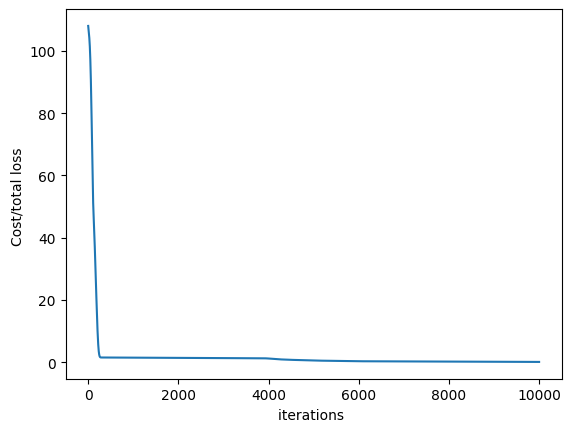

In [112]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.xlabel("iterations ")
plt.ylabel("Cost/total loss ")
plt.show()

In [113]:
df2 = pl.read_csv('/home/orfei/mestrado/progs/data_neural_network.txt')

In [114]:
mapper = {
    'Photon':1,
    'Proton':float(np.log(1)),
    'Iron':float(np.log(56))
}

trigs = []
for i in range(1,101):
    trig = 'TRIG' + str(i)
    trigs.append(trig)

trigs = dict((list(enumerate(trigs, 1))))

trigs = {value: key for key, value in trigs.items()}

df2 = df2.with_columns(
    pl.col('composition').map_dict(mapper, default=None),
    pl.col('TRIG').map_dict(trigs, default=None)
    )

df2_grouped = df2.group_by(["energy", "composition", "TRIG"]).agg([
    pl.col("density_normalized").first()
])

df2_neural = df2_grouped.pivot(
    values="density_normalized",
    index=["energy", "composition"],
    columns="TRIG"
)

df2_neural = df2_neural.with_columns(
      ((pl.col('energy').log10()))
    )

# Estrutura em ordem numérica
df2_neural = df2_neural.select(
    ['energy', 'composition'] + [f"{i}" for i in range(1, 101)]
)

In [115]:
df2_neural

energy,composition,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,…,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
14.0,1.0,0.000049,0.000068,0.000068,0.000083,0.000117,0.000076,0.000049,0.000095,0.000072,0.000049,0.000038,0.000098,0.000144,0.000129,0.00017,0.000193,0.000155,0.000106,0.000061,0.000091,0.000068,0.000091,0.000167,0.000276,0.000329,0.000261,0.000276,0.000197,0.000117,0.00011,0.000079,0.000155,0.000284,0.000367,0.000647,…,0.000416,0.000575,0.000647,0.000428,0.000246,0.000167,0.000132,0.000083,0.000083,0.000178,0.00028,0.000291,0.000288,0.000261,0.000151,0.000121,0.000079,0.000064,0.000098,0.000121,0.000106,0.000151,0.000182,0.000163,0.000087,0.000117,0.000064,0.000023,0.000079,0.000132,0.000117,0.000106,0.000098,0.000102,0.000102,0.000057,0.000038


In [116]:
columns = ['energy','composition']
y2 = df2_neural.select(columns)
x2 = df2_neural.select(pl.exclude(columns))

x2 = np.array(x2)
y2 = np.array(y2)

In [117]:
# Avaliação do modelo

model.eval()

# Previsão

input_tensor = torch.tensor(x2, dtype=torch.float32)

with torch.no_grad():
    prediction = model(input_tensor)


In [118]:
print(prediction)

tensor([[13.7048,  1.2524]])
